In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('placement_dataset (1).csv')

In [3]:
df.head()

,iq,cgpa,placement
0,107,6.19,0
1,98,6.63,0
2,110,6.28,0
3,123,7.13,1
4,96,8.44,0


In [5]:
df.duplicated().sum()

np.int64(1388)

In [6]:
df = df.drop_duplicates()

In [7]:
df.duplicated().sum()

np.int64(0)

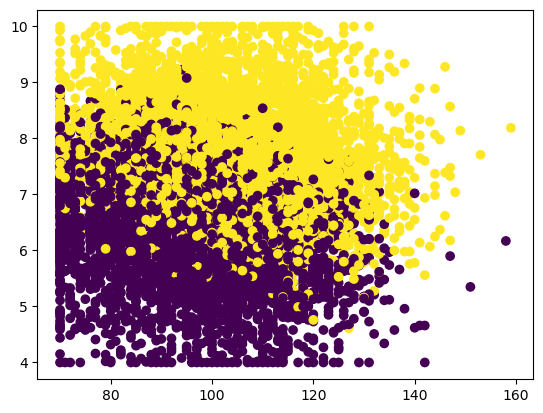

In [11]:
import matplotlib.pyplot as plt
plt.scatter(df['iq'],df['cgpa'],c=df['placement'])

In [24]:
# Feature Selection
X = df[['iq','cgpa']]
Y = df['placement']

In [25]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y, test_size=0.4, random_state=42)

In [26]:
X_train.shape

(5167, 2)

In [27]:
X_test.shape

(3445, 2)

In [28]:
from sklearn.preprocessing import StandardScaler

In [29]:
scaler = StandardScaler()

In [30]:
X_train = scaler.fit_transform(X_train)

In [32]:
X_test = scaler.transform(X_test)

In [33]:
from sklearn.linear_model import LogisticRegression

In [34]:
model = LogisticRegression()

In [35]:
model.fit(X_train,Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [37]:
Y_pred=model.predict(X_test)

In [38]:
from sklearn.metrics import accuracy_score

In [39]:
accuracy_score(Y_pred,Y_test)

0.7994194484760523

In [40]:
import pickle

In [44]:
pickle.dump(model,open('model.pkl','wb'))